In [ ]:
from google.colab import files
uploaded = files.upload()


Saving CO2_FFC.xlsx to CO2_FFC.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
df.head()



,Year,Company,Vehicle Fleet Size,Distance Travelled (km),Fuel Consumption (Liters),CO2 Emission (After) (tons),Green Supply Initiatives
0,2019,Fauji Fertilizer Co.,50,500000,50000,95000,- Regular diesel-powered trucks<br>- No specif...
1,2020,Fauji Fertilizer Co.,55,550000,55000,92500,- Increased vehicle maintenance to improve fue...
2,2021,Fauji Fertilizer Co.,60,600000,60000,89000,- Replacement of 10 old trucks with electric v...
3,2022,Fauji Fertilizer Co.,58,580000,58000,85500,- Continued use of biofuel in 10% of the fleet...


In [ ]:
df.shape

(4, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Year                         4 non-null      int64 
 1   Company                      4 non-null      object
 2   Vehicle Fleet Size           4 non-null      int64 
 3   Distance Travelled (km)      4 non-null      int64 
 4   Fuel Consumption (Liters)    4 non-null      int64 
 5   CO2 Emission (After) (tons)  4 non-null      int64 
 6   Green Supply Initiatives     4 non-null      object
dtypes: int64(5), object(2)
memory usage: 356.0+ bytes


In [ ]:
df.describe()

,Year,Vehicle Fleet Size,Distance Travelled (km),Fuel Consumption (Liters),CO2 Emission (After) (tons)
count,4.000000,4.000000,4.000000,4.00000,4.000000
mean,2020.500000,55.750000,557500.000000,55750.00000,90500.000000
std,1.290994,4.349329,43493.294502,4349.32945,4143.267632
min,2019.000000,50.000000,500000.000000,50000.00000,85500.000000
25%,2019.750000,53.750000,537500.000000,53750.00000,88125.000000
50%,2020.500000,56.500000,565000.000000,56500.00000,90750.000000
75%,2021.250000,58.500000,585000.000000,58500.00000,93125.000000
max,2022.000000,60.000000,600000.000000,60000.00000,95000.000000


In [ ]:
df.columns = df.columns.str.strip()  # remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_")  # replace spaces with _
df.columns = df.columns.str.replace("(", "")  # remove '('
df.columns = df.columns.str.replace(")", "")  # remove ')'
df.columns = df.columns.str.lower()  # convert to lowercase

df.columns.tolist()



['year',
 'company',
 'vehicle_fleet_size',
 'distance_travelled_km',
 'fuel_consumption_liters',
 'co2_emission_after_tons',
 'green_supply_initiatives',
 'date']

In [ ]:
df.isnull().sum()


,0
year,0
company,0
vehicle_fleet_size,0
distance_travelled_km,0
fuel_consumption_liters,0
co2_emission_after_tons,0
green_supply_initiatives,0
date,0


**EXPLORATORY DATA ANALYSIS (VISUAL)**

In [ ]:
df.columns

Index(['year', 'company', 'vehicle_fleet_size', 'distance_travelled_km',
       'fuel_consumption_liters', 'co2_emission_after_tons',
       'green_supply_initiatives', 'date'],
      dtype='object')

In [ ]:
num_cols = [
    'vehicle_fleet_size',
    'distance_travelled_km',
    'fuel_consumption_liters',
    'co2_emission_after_tons'
]


In [ ]:
df['date'] = pd.to_datetime(df['year'], format='%Y')
df = df.sort_values('date')


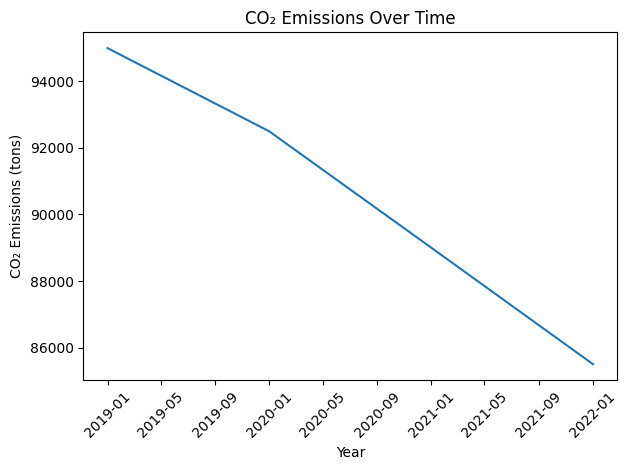

In [ ]:
df['date'] = pd.to_datetime(df['year'], format='%Y')
df = df.sort_values('date')

ts = df.groupby('date')['co2_emission_after_tons'].sum()

plt.figure()
plt.plot(ts)
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (tons)")
plt.title("CO₂ Emissions Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




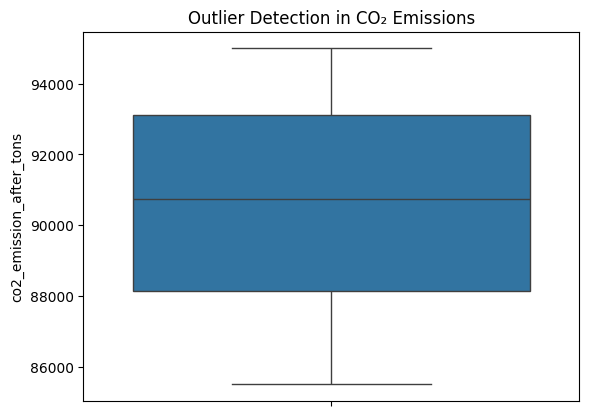

In [ ]:
plt.figure()
sns.boxplot(y=df['co2_emission_after_tons'])
plt.title("Outlier Detection in CO₂ Emissions")
plt.show()


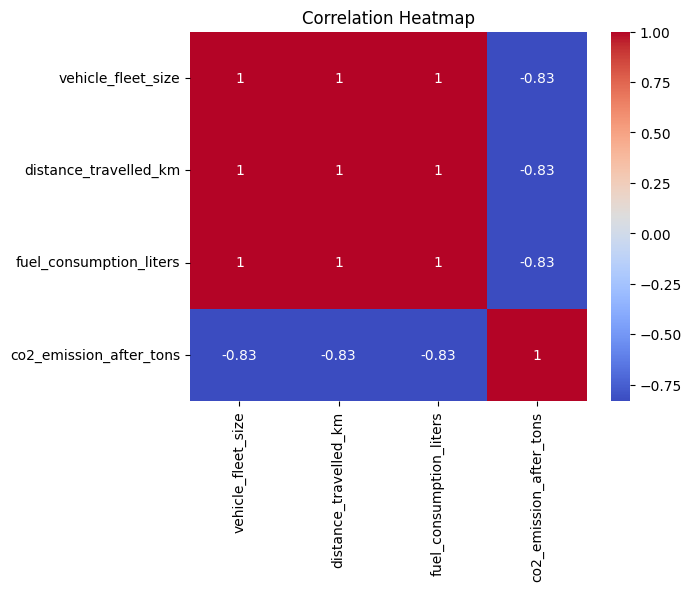

In [ ]:
plt.figure()
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



**TIME SERIES ANALYSIS & FORECASTING**

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 1.4021363680319514
p-value: 0.9971238255046102


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


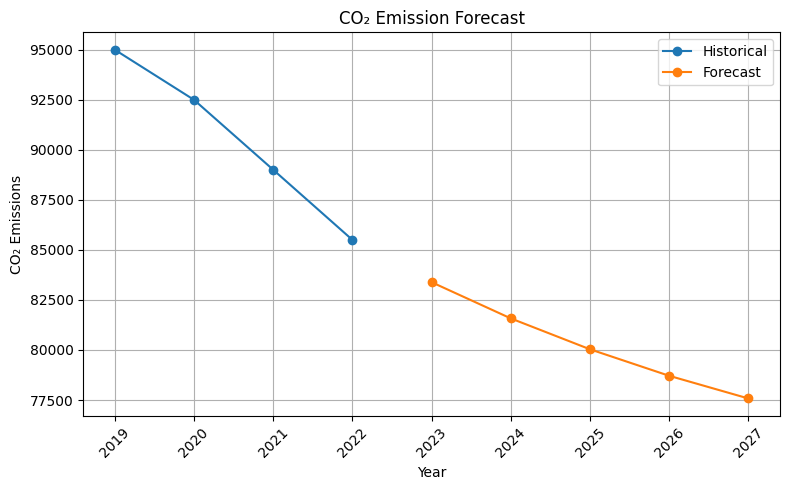

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(ts.index, ts.values, marker="o", label="Historical")
plt.plot(forecast.index, forecast.values, marker="o", label="Forecast")

plt.title("CO₂ Emission Forecast")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




**PREDICTIVE ANALYSIS (ML)**

In [ ]:
features = [
    'vehicle_fleet_size',
    'distance_travelled_km',
    'fuel_consumption_liters'
]

X = df[features]
y = df['co2_emission_after_tons']





In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: nan
MAE: 4580.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


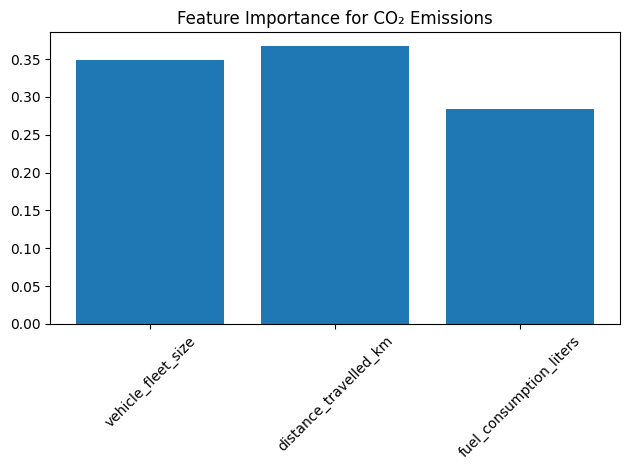

In [ ]:
import numpy as np

importances = rf.feature_importances_

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance for CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
